In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("/kaggle/input/datasets/uciml/iris/Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [2]:
print(df["Species"].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [3]:
print(df.isnull().sum())
print(df.isna().sum())
print("Количество дубликатов:", df.duplicated().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
Количество дубликатов: 0


In [4]:
df = df.drop(columns=["Id"])

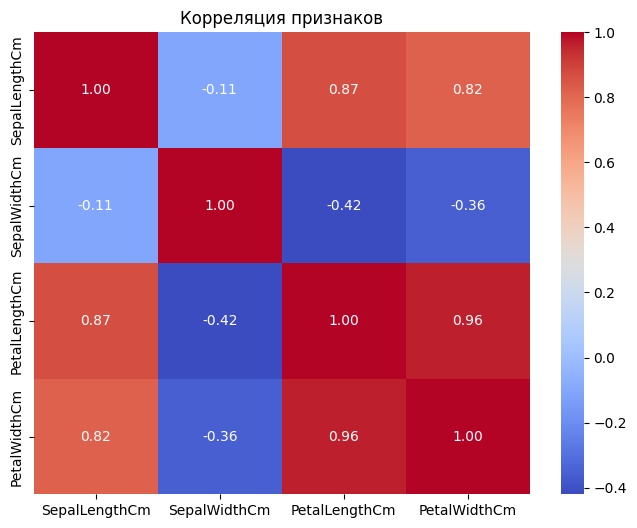

In [5]:
X = df.drop(columns=["Species"])
y = df["Species"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляция признаков")
plt.show()

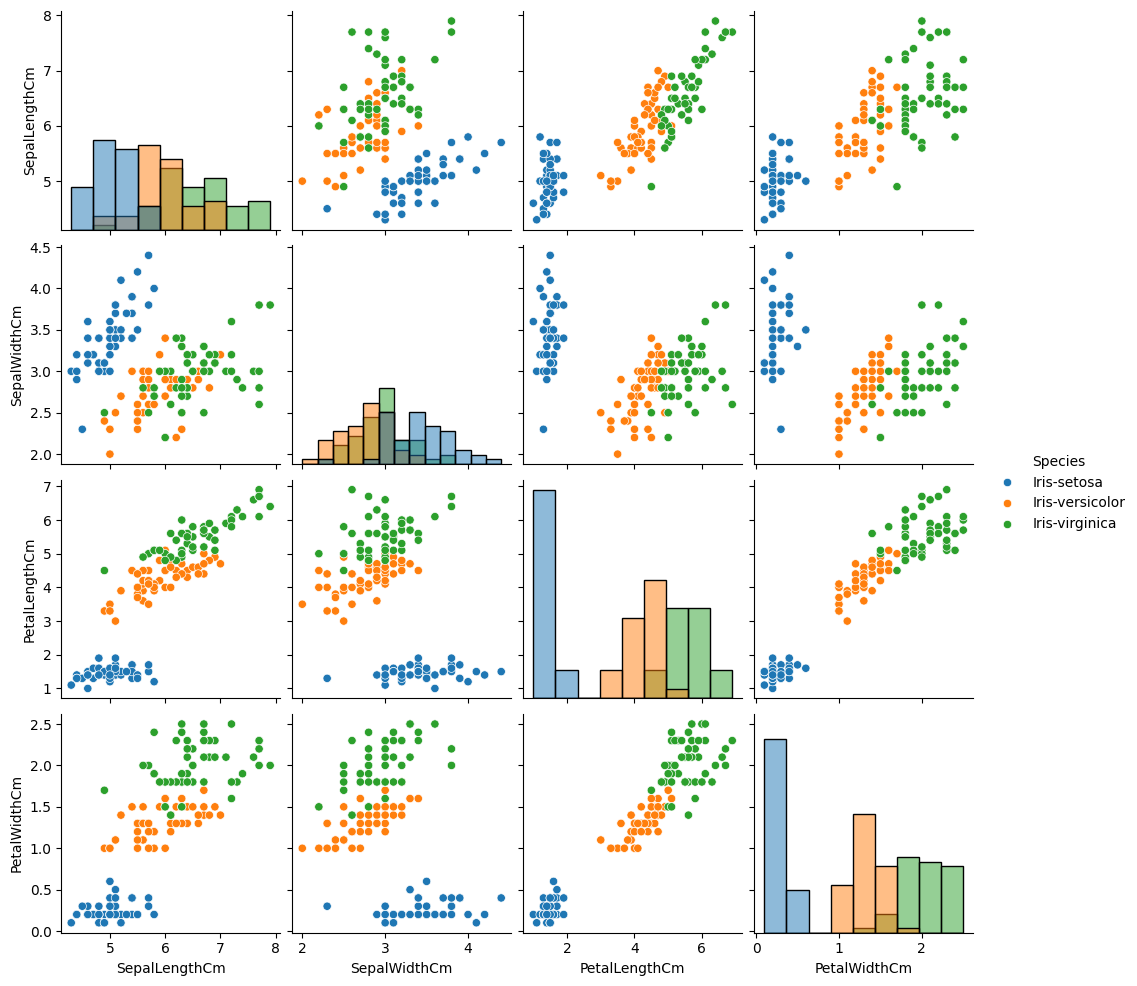

In [6]:
sns.pairplot(
    df,
    hue="Species",
    diag_kind="hist"
)

plt.show()

Уже здесь видна очень хорошая кластеризация. Выполню небольшой сайд-квест и попробую разделить виды простым PCA.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

pca_df["Species"] = y_train.values

print(pca_df.head())

        PC1       PC2          Species
0 -2.362868 -1.007809      Iris-setosa
1  0.317467 -1.482384   Iris-virginica
2  1.226343 -0.094959  Iris-versicolor
3 -2.199332 -0.388537      Iris-setosa
4  0.232576 -1.277702  Iris-versicolor


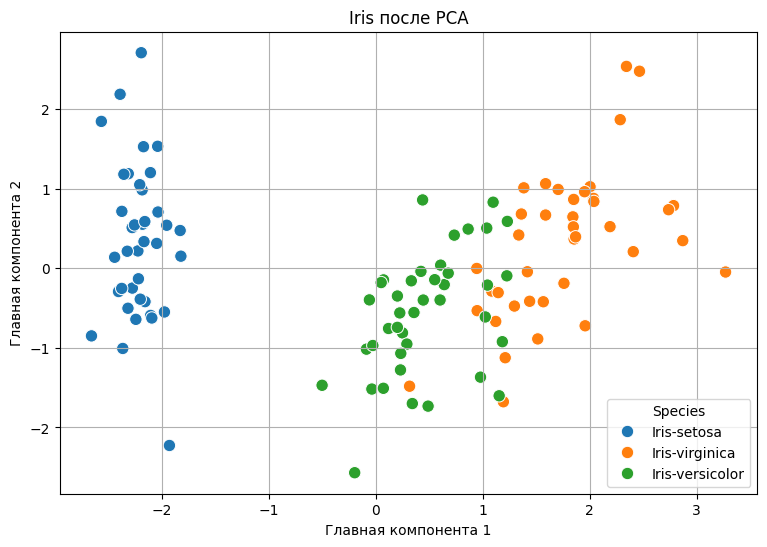

In [10]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Species",
    s=80
)

plt.title("Iris после PCA")
plt.xlabel("Главная компонента 1")
plt.ylabel("Главная компонента 2")
plt.grid(True)
plt.show()

Ладно, если честно, не настолько чистые кластеры, как я ожидала. Хотя это все равно отличный результат. Тем не менее, возвращаемся к KNN.

Надо подобрать оптимальный k. Т.к. датасет маленький, подбирать можно тупым перебором: от 1 до 50, где 50 - это количество объектов класса.

In [11]:
k_values = range(1, 51)

accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy_scores.append(
        accuracy_score(y_test, y_pred)
    )

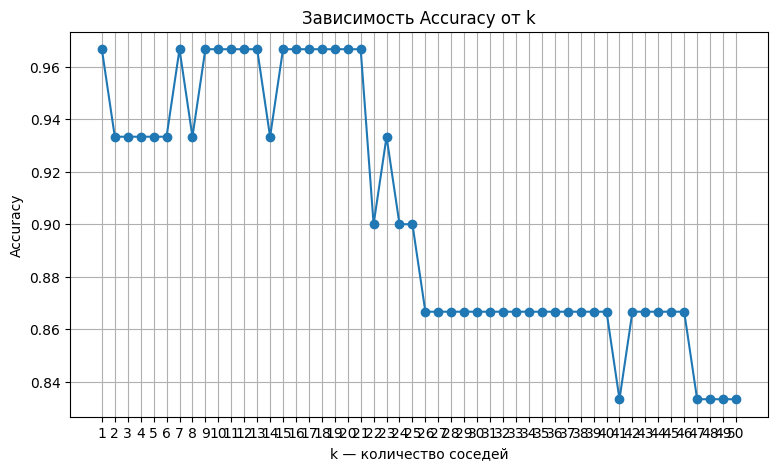

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.xlabel("k — количество соседей")
plt.ylabel("Accuracy")
plt.title("Зависимость Accuracy от k")

plt.xticks(k_values)
plt.grid(True)

plt.show()

После 21 соседа аккуратность резко падает. Но выбрать между k от 1 до 20, которые дают одинаковые результаты, все еще трудно. Можно в целом тыкать наобум, но я попробую сделать кросс-валидацию.

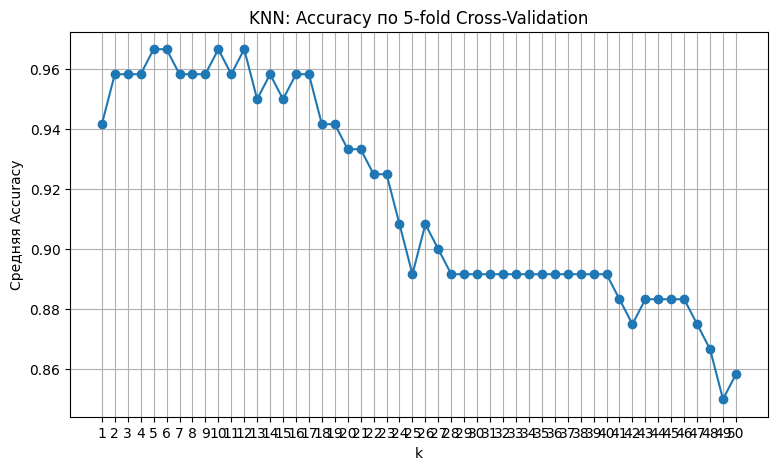

In [13]:
from sklearn.model_selection import cross_val_score

k_values = range(1, 51)

cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    cv_scores,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Средняя Accuracy")
plt.title("KNN: Accuracy по 5-fold Cross-Validation")
plt.xticks(k_values)
plt.grid(True)

plt.show()

Все еще огромный диапазон допустимого k. Данные слишком хороши. Колебания в пределах случайности. Если честно, тут можно было бы вручную расставить пороги по признакам и получить нормальную классификацию, но раз уж взялись, то пусть будет k = 10.

In [14]:
best_k = 10

knn_best = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)

Попробуем также weighted, не отходя от кассы. Считать вес будем от дистанции: ближе сосед - больше вес.

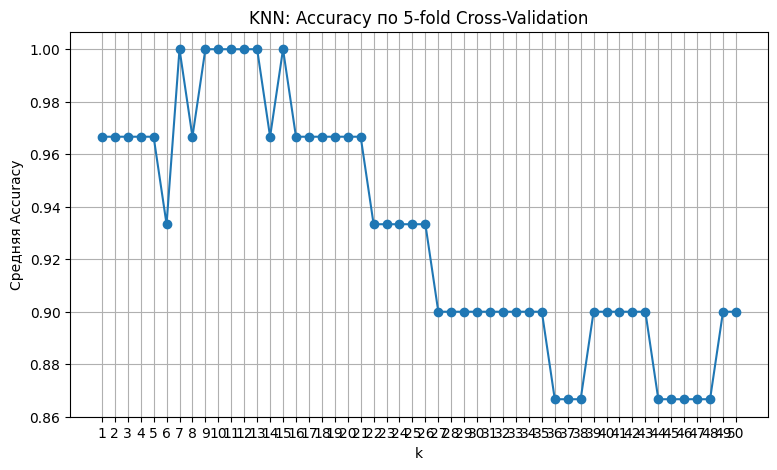

In [15]:
weighted_accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    weighted_accuracy_scores.append(
        accuracy_score(y_test, y_pred)
    )

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    weighted_accuracy_scores,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Средняя Accuracy")
plt.title("KNN: Accuracy по 5-fold Cross-Validation")
plt.xticks(k_values)
plt.grid(True)

plt.show()

Легким движением руки мы добились accuracy = 1.0. В другой ситуации я бы сказала, что это утечка, но нет, это датасет такой.

In [16]:
knn_final = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_weighted_final = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance"
)

knn_final.fit(X_train_scaled, y_train)
knn_weighted_final.fit(X_train_scaled, y_train)

pred_knn = knn_final.predict(X_test_scaled)
pred_weighted = knn_weighted_final.predict(X_test_scaled)

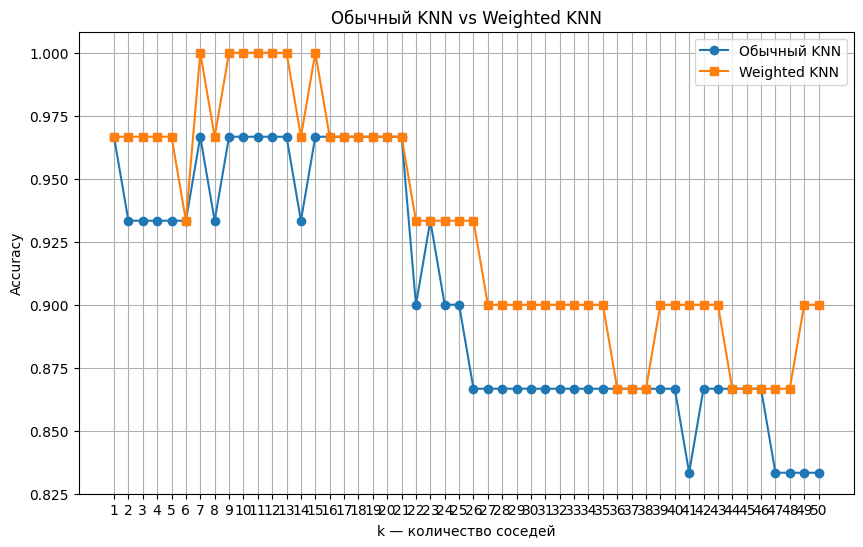

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o",
    label="Обычный KNN"
)

plt.plot(
    k_values,
    weighted_accuracy_scores,
    marker="s",
    label="Weighted KNN"
)

plt.xlabel("k — количество соседей")
plt.ylabel("Accuracy")
plt.title("Обычный KNN vs Weighted KNN")

plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()

Внезапно добавилось задание сравнить weights='uniform' и weights='distance'. Также добавилось задание попробовать обучить модель на исходных признаках без скейлинга.

weights = uniform у нас уже есть, оно как дефолтное (т.е. первая модель - это оно). Для простоты кода, просто переделаю все.

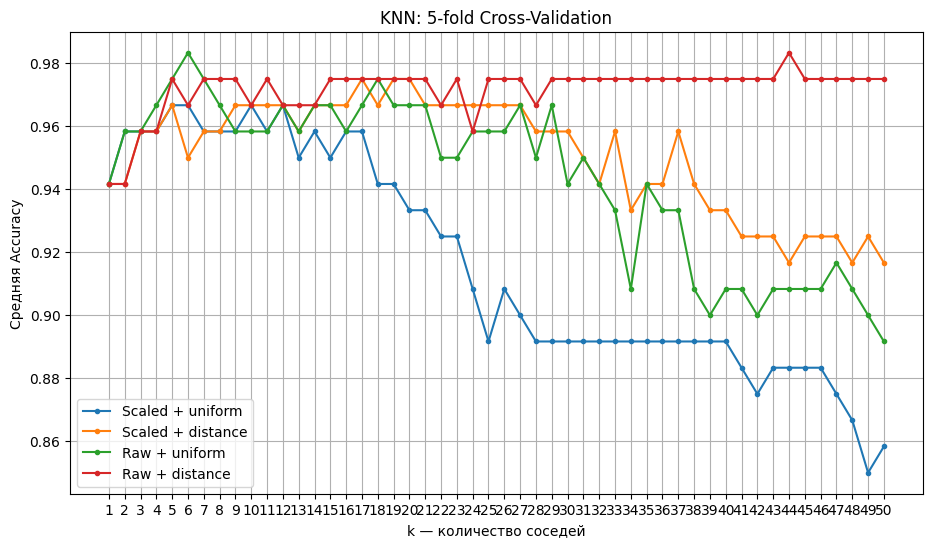

In [18]:
cv_results = {
    "Scaled + uniform": [],
    "Scaled + distance": [],
    "Raw + uniform": [],
    "Raw + distance": []
}

for k in k_values:
    models = {
        "Scaled + uniform": (
            KNeighborsClassifier(
                n_neighbors=k,
                weights="uniform"
            ),
            X_train_scaled
        ),
        "Scaled + distance": (
            KNeighborsClassifier(
                n_neighbors=k,
                weights="distance"
            ),
            X_train_scaled
        ),
        "Raw + uniform": (
            KNeighborsClassifier(
                n_neighbors=k,
                weights="uniform"
            ),
            X_train
        ),
        "Raw + distance": (
            KNeighborsClassifier(
                n_neighbors=k,
                weights="distance"
            ),
            X_train
        )
    }

    for name, (model, X_data) in models.items():

        scores = cross_val_score(
            model,
            X_data,
            y_train,
            cv=5,
            scoring="accuracy"
        )

        cv_results[name].append(scores.mean())

plt.figure(figsize=(11, 6))

for name, scores in cv_results.items():
    plt.plot(
        k_values,
        scores,
        marker="o",
        markersize=3,
        label=name
    )

plt.xlabel("k — количество соседей")
plt.ylabel("Средняя Accuracy")
plt.title("KNN: 5-fold Cross-Validation")
plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()

Прикольно. Raw+Distance вообще безразлично количество соседей, при этом качество остается стабильно высоким.

Причины:
- почему distance не деградирует, а uniform деградирует: distance позволяет включить много соседей, но фактически дать наибольший вклад ближайшим.
- почему raw не деградирует, а scaled деградирует? Гипотеза: так совпало, что признаки, которые лучше всего разделяют ирисы, заодно имеют наибольший масштаб. (Ужасный датасет, ужасный). Проверим ее.

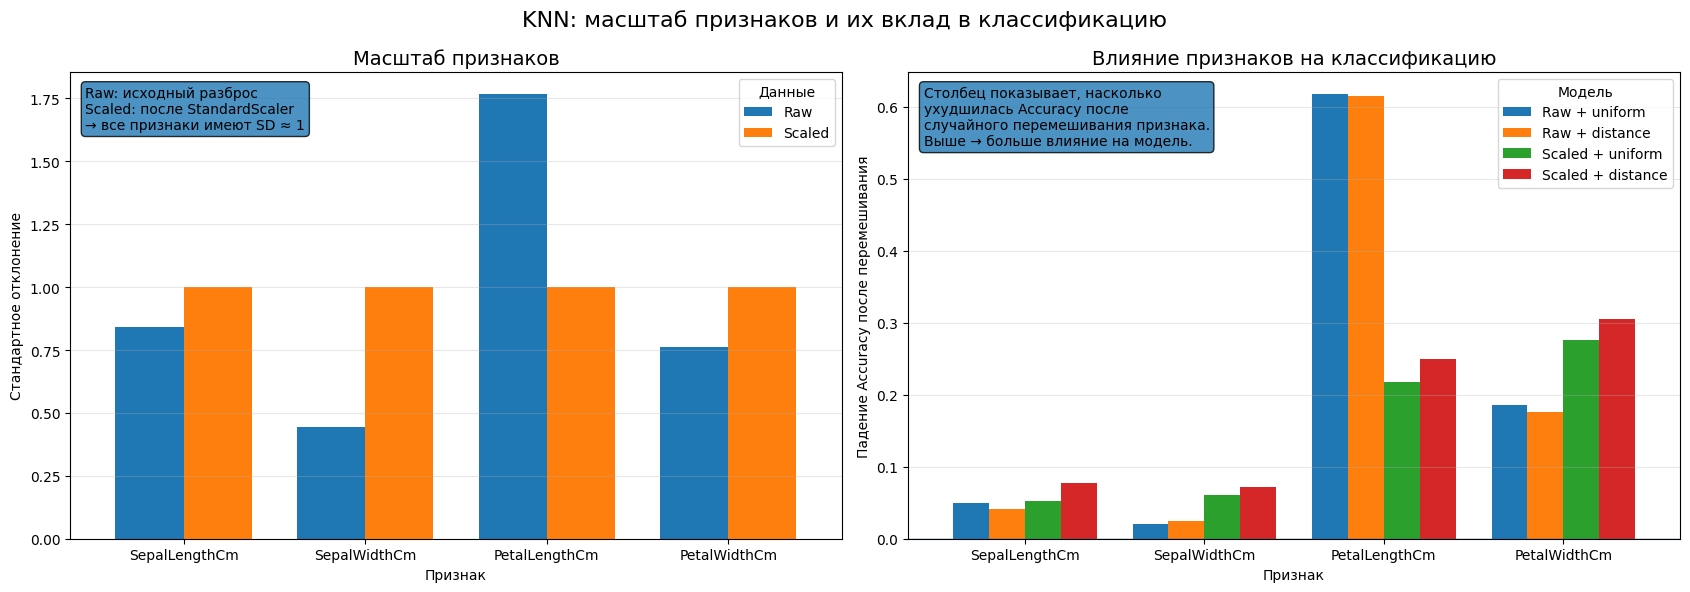

In [19]:
from sklearn.inspection import permutation_importance

# ============================================================
# Данные для графика
# ============================================================

# Масштаб признаков
scale_df = pd.DataFrame({
    "Raw": X_train.std(),
    "Scaled": X_train_scaled.std(axis=0)
}, index=X.columns)

# Важность признаков для 4 моделей
models = {
    "Raw + uniform": (
        KNeighborsClassifier(n_neighbors=10, weights="uniform"),
        X_train, X_test
    ),
    "Raw + distance": (
        KNeighborsClassifier(n_neighbors=10, weights="distance"),
        X_train, X_test
    ),
    "Scaled + uniform": (
        KNeighborsClassifier(n_neighbors=10, weights="uniform"),
        X_train_scaled, X_test_scaled
    ),
    "Scaled + distance": (
        KNeighborsClassifier(n_neighbors=10, weights="distance"),
        X_train_scaled, X_test_scaled
    )
}

importance_results = {}

for name, (model, X_tr, X_te) in models.items():

    model.fit(X_tr, y_train)

    result = permutation_importance(
        model,
        X_te,
        y_test,
        scoring="accuracy",
        n_repeats=30,
        random_state=42
    )

    importance_results[name] = result.importances_mean

importance_df = pd.DataFrame(
    importance_results,
    index=X.columns
)

# ============================================================
# ОДНА ПАНЕЛЬ — два barplot
# ============================================================

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(17, 6)
)

# ------------------------------------------------------------
# СЛЕВА: масштаб признаков
# ------------------------------------------------------------

scale_df.plot(
    kind="bar",
    ax=ax1,
    width=0.75
)

ax1.set_title(
    "Масштаб признаков",
    fontsize=14
)

ax1.set_xlabel("Признак")
ax1.set_ylabel("Стандартное отклонение")

ax1.set_xticklabels(
    X.columns,
    rotation=0
)

ax1.grid(
    axis="y",
    alpha=0.3
)

ax1.legend(
    title="Данные"
)

ax1.text(
    0.02,
    0.97,
    "Raw: исходный разброс\n"
    "Scaled: после StandardScaler\n"
    "→ все признаки имеют SD ≈ 1",
    transform=ax1.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

# ------------------------------------------------------------
# СПРАВА: важность признаков
# ------------------------------------------------------------

importance_df.plot(
    kind="bar",
    ax=ax2,
    width=0.8
)

ax2.axhline(
    0,
    linewidth=1
)

ax2.set_title(
    "Влияние признаков на классификацию",
    fontsize=14
)

ax2.set_xlabel("Признак")
ax2.set_ylabel(
    "Падение Accuracy после перемешивания"
)

ax2.set_xticklabels(
    X.columns,
    rotation=0
)

ax2.grid(
    axis="y",
    alpha=0.3
)

ax2.legend(
    title="Модель"
)

ax2.text(
    0.02,
    0.97,
    "Столбец показывает, насколько\n"
    "ухудшилась Accuracy после\n"
    "случайного перемешивания признака.\n"
    "Выше → больше влияние на модель.",
    transform=ax2.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

plt.suptitle(
    "KNN: масштаб признаков и их вклад в классификацию",
    fontsize=16
)

plt.tight_layout()
plt.show()

Гипотеза подтвердилась. Модели без скейлинга смотрят практически исключительно на petal length, т.к. у этого признака больше масштаб. Модели со скейлингом при этом в равной степени смотрят на ширину и длину лепестков. Занимательно, что конкретно на этом датасете это работает немного хуже. Различие в пределах погрешности, но модель, которая смотрит, фактически, только на один признак, оказывается устойчивее к росту числа соседей. Как я и говорила выше: можно просто руками провести границы классификации и будет норм.

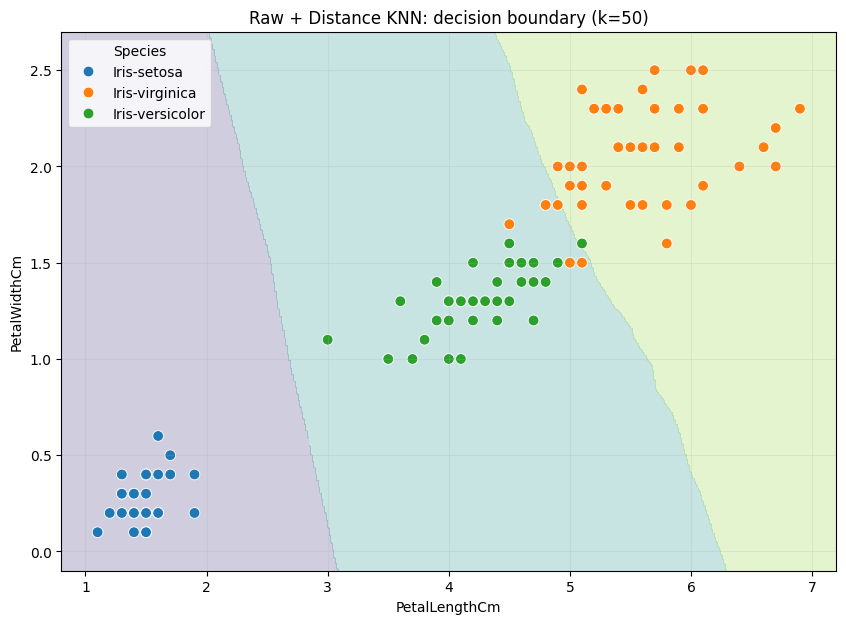

In [20]:
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# Raw + distance, k=50
# ============================================================

model = KNeighborsClassifier(
    n_neighbors=50,
    weights="distance"
)

model.fit(X_train, y_train)

# Берём два признака для визуализации
x_feature = "PetalLengthCm"
y_feature = "PetalWidthCm"

X_plot = X_train[[x_feature, y_feature]]

# Сетка
x_min, x_max = X_plot[x_feature].min() - 0.3, X_plot[x_feature].max() + 0.3
y_min, y_max = X_plot[y_feature].min() - 0.2, X_plot[y_feature].max() + 0.2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Для остальных признаков фиксируем средние значения
X_grid = pd.DataFrame(
    np.tile(X_train.mean().values, (xx.ravel().shape[0], 1)),
    columns=X_train.columns
)

X_grid[x_feature] = xx.ravel()
X_grid[y_feature] = yy.ravel()

# Предсказания модели
Z = model.predict(X_grid).reshape(xx.shape)

# Перевод классов в числа для contour
class_to_num = {
    cls: i for i, cls in enumerate(model.classes_)
}

Z_num = np.vectorize(class_to_num.get)(Z)

# ============================================================
# График
# ============================================================

plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_num,
    alpha=0.25,
    levels=np.arange(len(model.classes_) + 1) - 0.5
)

sns.scatterplot(
    data=X_train.assign(Species=y_train.values),
    x=x_feature,
    y=y_feature,
    hue="Species",
    s=60
)

plt.xlabel(x_feature)
plt.ylabel(y_feature)

plt.title(
    "Raw + Distance KNN: decision boundary (k=50)"
)

plt.grid(alpha=0.2)
plt.legend(title="Species")
plt.show()

Вот кстати интересно, но нет, границы не совсем вертикальные. Но близки к тому.

Еще просят визуализацию признаков. Ну ладно

In [21]:
features_2d = [
    "PetalLengthCm",
    "PetalWidthCm"
]

X_2d = df[features_2d]
y_2d = df["Species"]

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

scaler_2d = StandardScaler()

X_2d_train_scaled = scaler_2d.fit_transform(X_2d_train)
X_2d_test_scaled = scaler_2d.transform(X_2d_test)

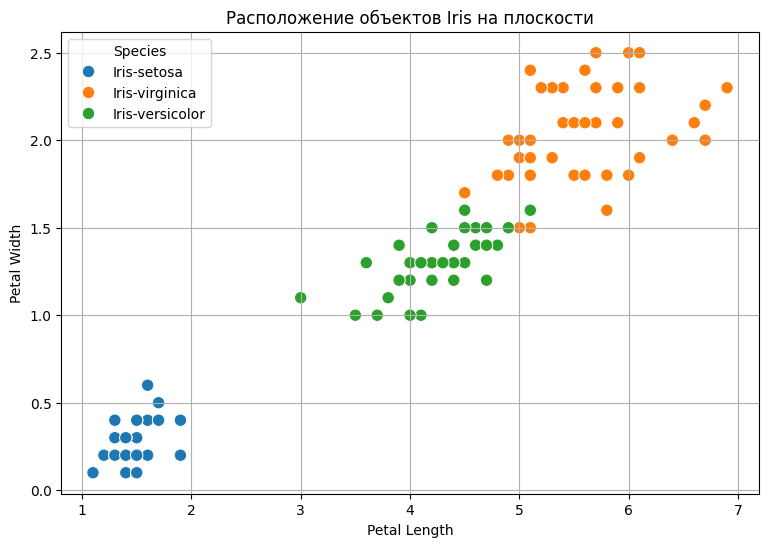

In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_2d_train[features_2d[0]],
    y=X_2d_train[features_2d[1]],
    hue=y_2d_train,
    s=80
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Расположение объектов Iris на плоскости")
plt.grid(True)

plt.show()

И границы решений

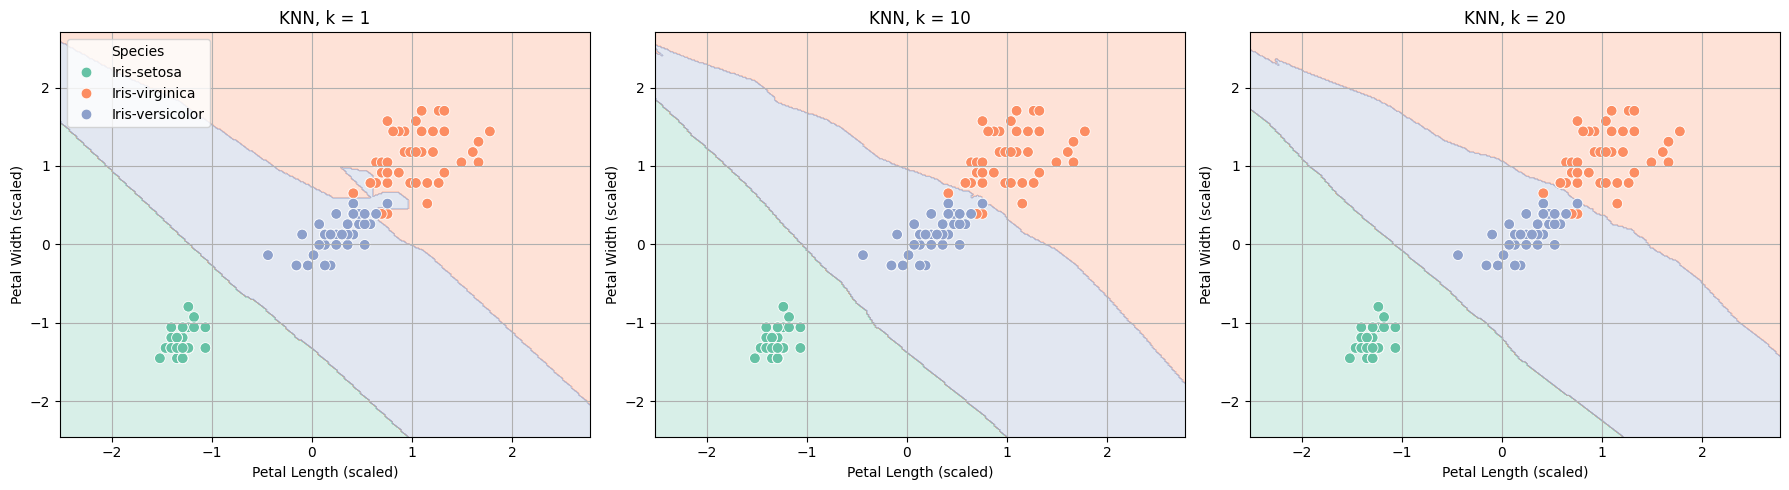

In [23]:
from matplotlib.colors import ListedColormap

k_values_visualization = [1, 10, 20]

x_min = X_2d_train_scaled[:, 0].min() - 1
x_max = X_2d_train_scaled[:, 0].max() + 1
y_min = X_2d_train_scaled[:, 1].min() - 1
y_max = X_2d_train_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Преобразуем классы в числа для построения границы
classes = y_2d_train.unique()
class_to_num = {cls: i for i, cls in enumerate(classes)}
y_train_num = y_2d_train.map(class_to_num)

cmap = ListedColormap(
    sns.color_palette("Set2", n_colors=3)
)

plt.figure(figsize=(18, 5))

for i, k in enumerate(k_values_visualization, 1):

    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform"
    )

    model.fit(X_2d_train_scaled, y_2d_train)

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z_num = np.array([class_to_num[label] for label in Z])
    Z_num = Z_num.reshape(xx.shape)

    plt.subplot(1, 3, i)

    plt.contourf(
        xx,
        yy,
        Z_num,
        alpha=0.25,
        cmap=cmap
    )

    sns.scatterplot(
        x=X_2d_train_scaled[:, 0],
        y=X_2d_train_scaled[:, 1],
        hue=y_2d_train,
        palette="Set2",
        s=60,
        legend=(i == 1)
    )

    plt.xlabel("Petal Length (scaled)")
    plt.ylabel("Petal Width (scaled)")
    plt.title(f"KNN, k = {k}")
    plt.grid(True)

plt.tight_layout()
plt.show()